In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [54]:
# Load the dataset
df = pd.read_csv(r'C:\Users\chand\OneDrive\Student Success Analytics\Student_performance_data.csv')

df.shape

(2392, 15)

In [55]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [56]:
df.isnull().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [57]:
df.dtypes

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

In [58]:
# Check what the numeric codes actually mean
print("Gender:", df['Gender'].unique())
print("Ethnicity:", df['Ethnicity'].unique())
print("ParentalEducation:", df['ParentalEducation'].unique())
print("ParentalSupport:", df['ParentalSupport'].unique())
print("GradeClass:", df['GradeClass'].unique())

Gender: [1 0]
Ethnicity: [0 2 1 3]
ParentalEducation: [2 1 3 4 0]
ParentalSupport: [2 1 3 4 0]
GradeClass: [2. 1. 4. 3. 0.]


In [59]:
# Decode categorical columns into readable labels
df['Gender'] = df['Gender'].map({0: 'Male', 1: 'Female'})

df['Ethnicity'] = df['Ethnicity'].map({
    0: 'Caucasian', 1: 'African American', 
    2: 'Asian', 3: 'Other'
})

df['ParentalEducation'] = df['ParentalEducation'].map({
    0: 'None', 1: 'High School', 
    2: 'Some College', 3: 'Bachelors', 4: 'Higher'
})

df['ParentalSupport'] = df['ParentalSupport'].map({
    0: 'None', 1: 'Low', 2: 'Moderate', 
    3: 'High', 4: 'Very High'
})

df['Tutoring'] = df['Tutoring'].map({0: 'No', 1: 'Yes'})
df['Extracurricular'] = df['Extracurricular'].map({0: 'No', 1: 'Yes'})
df['Sports'] = df['Sports'].map({0: 'No', 1: 'Yes'})
df['Music'] = df['Music'].map({0: 'No', 1: 'Yes'})
df['Volunteering'] = df['Volunteering'].map({0: 'No', 1: 'Yes'})

df['GradeClass'] = df['GradeClass'].map({
    0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'F'
})

# Verify
print(df.head())
print(df.dtypes)

   StudentID  Age  Gender  Ethnicity ParentalEducation  StudyTimeWeekly  \
0       1001   17  Female  Caucasian      Some College        19.833723   
1       1002   18    Male  Caucasian       High School        15.408756   
2       1003   15    Male      Asian         Bachelors         4.210570   
3       1004   17  Female  Caucasian         Bachelors        10.028829   
4       1005   17  Female  Caucasian      Some College         4.672495   

   Absences Tutoring ParentalSupport Extracurricular Sports Music  \
0         7      Yes        Moderate              No     No   Yes   
1         0       No             Low              No     No    No   
2        26       No        Moderate              No     No    No   
3        14       No            High             Yes     No    No   
4        17      Yes            High              No     No    No   

  Volunteering       GPA GradeClass  
0           No  2.929196          C  
1           No  3.042915          B  
2           No  0.11

In [60]:
df.describe()

,StudentID,Age,StudyTimeWeekly,Absences,GPA
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,9.771992,14.541388,1.906186
std,690.655244,1.123798,5.652774,8.467417,0.915156
min,1001.000000,15.000000,0.001057,0.000000,0.000000
25%,1598.750000,15.000000,5.043079,7.000000,1.174803
50%,2196.500000,16.000000,9.705363,15.000000,1.893393
75%,2794.250000,17.000000,14.408410,22.000000,2.622216
max,3392.000000,18.000000,19.978094,29.000000,4.000000


In [61]:
df[['StudyTimeWeekly', 'Absences', 'Age', 'GPA']].describe()

,StudyTimeWeekly,Absences,Age,GPA
count,2392.000000,2392.000000,2392.000000,2392.000000
mean,9.771992,14.541388,16.468645,1.906186
std,5.652774,8.467417,1.123798,0.915156
min,0.001057,0.000000,15.000000,0.000000
25%,5.043079,7.000000,15.000000,1.174803
50%,9.705363,15.000000,16.000000,1.893393
75%,14.408410,22.000000,17.000000,2.622216
max,19.978094,29.000000,18.000000,4.000000


In [62]:
grade_dist = df['GradeClass'].value_counts().sort_index()
grade_dist

GradeClass
A     107
B     269
C     391
D     414
F    1211
Name: count, dtype: int64

In [63]:
print("\nGrade Distribution %:")
print((grade_dist / len(df) * 100).round(2))


Grade Distribution %:
GradeClass
A     4.47
B    11.25
C    16.35
D    17.31
F    50.63
Name: count, dtype: float64


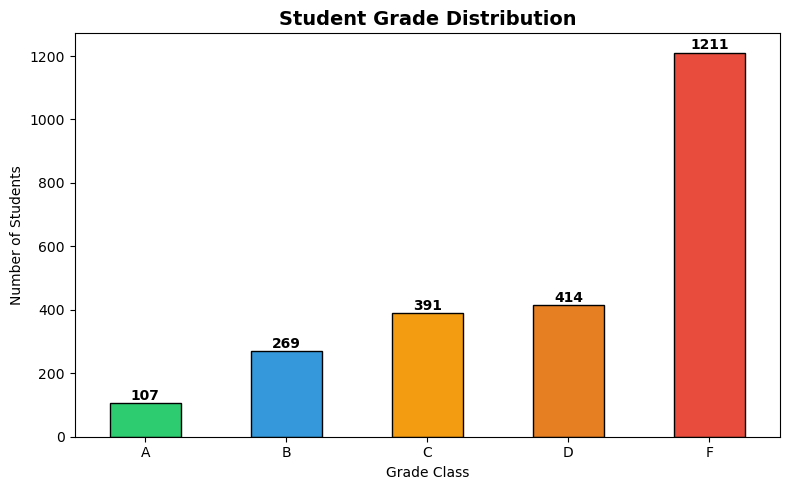

In [64]:
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
grade_dist.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Student Grade Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Grade Class')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)

# Add count labels on each bar
for i, v in enumerate(grade_dist):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('grade_distribution.png', dpi=150)
plt.show()

Correlation with GPA:
StudyTimeWeekly    0.179
Age                0.000
Absences          -0.919
Name: GPA, dtype: float64


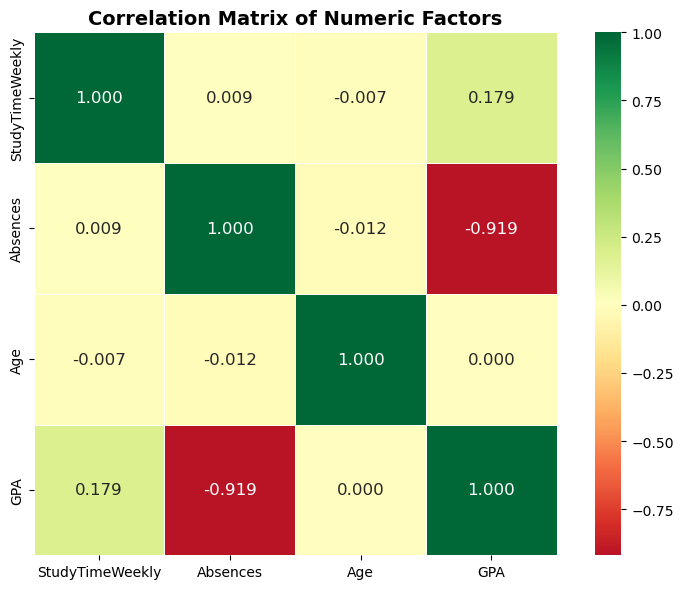

In [65]:
# Correlation of numeric factors with GPA
numeric_cols = ['StudyTimeWeekly', 'Absences', 'Age']
correlations = df[numeric_cols + ['GPA']].corr()['GPA'].drop('GPA').sort_values(ascending=False)

print("Correlation with GPA:")
print(correlations.round(3))

# Visualize
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df[['StudyTimeWeekly', 'Absences', 'Age', 'GPA']].corr().round(3)

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.3f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 12})

plt.title('Correlation Matrix of Numeric Factors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

Finding 1: Absences has a -0.919 correlation with GPA — the strongest risk factor by far

In [66]:
from scipy import stats

# ANOVA — does GPA differ significantly across GradeClass groups?
# Test: does study time significantly differ between grade groups?
groups = [df[df['GradeClass'] == g]['StudyTimeWeekly'] for g in ['A', 'B', 'C', 'D', 'F']]
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA - StudyTime across Grade Groups:")
print(f"F-statistic: {f_stat:.3f}, P-value: {p_value:.6f}")

# Same for Absences
groups_abs = [df[df['GradeClass'] == g]['Absences'] for g in ['A', 'B', 'C', 'D', 'F']]
f_stat2, p_value2 = stats.f_oneway(*groups_abs)
print(f"\nANOVA - Absences across Grade Groups:")
print(f"F-statistic: {f_stat2:.3f}, P-value: {p_value2:.6f}")

ANOVA - StudyTime across Grade Groups:
F-statistic: 11.269, P-value: 0.000000

ANOVA - Absences across Grade Groups:
F-statistic: 903.118, P-value: 0.000000


Finding 2: ANOVA confirms both absences and study time differ significantly across grade groups (p < 0.0001), meaning these are real patterns, not random

In [67]:
# Average GPA and Absences by Grade Group
segment = df.groupby('GradeClass').agg(
    Student_Count=('StudentID', 'count'),
    Avg_GPA=('GPA', 'mean'),
    Avg_Absences=('Absences', 'mean'),
    Avg_StudyTime=('StudyTimeWeekly', 'mean')
).round(2)

# Sort by GPA descending
segment = segment.reindex(['A', 'B', 'C', 'D', 'F'])
print(segment)

            Student_Count  Avg_GPA  Avg_Absences  Avg_StudyTime
GradeClass                                                     
A                     107     3.10          5.75          11.85
B                     269     3.00          5.31          11.12
C                     391     2.66          7.25          10.11
D                     414     2.22         11.43           9.76
F                    1211     1.21         20.79           9.18


Finding 3 — Absences perfectly separates grade groups.
A students miss 5-6 days. F students miss nearly 21 days. That's a 3.6x difference in absences between A and F students. Study time difference is much smaller — only 2.67 hours separates A and F students. This confirms absences is the dominant factor.

In [68]:
# GPA by Parental Education level
print("\nAvg GPA by Parental Education:")
print(df.groupby('ParentalEducation')['GPA'].mean().round(2).sort_values(ascending=False))



Avg GPA by Parental Education:
ParentalEducation
High School     1.94
Some College    1.93
None            1.89
Higher          1.82
Bachelors       1.81
Name: GPA, dtype: float64


Finding 4 — Parental Education barely matters:
GPA ranges from 1.81 to 1.94 across all education levels — that's a difference of only 0.13. Statistically almost meaningless. Counterintuitive finding — parental education level does not significantly affect student GPA in this dataset.

In [69]:
# GPA by Parental Support
print("\nAvg GPA by Parental Support:")
print(df.groupby('ParentalSupport')['GPA'].mean().round(2).sort_values(ascending=False))



Avg GPA by Parental Support:
ParentalSupport
Very High    2.19
High         2.04
Moderate     1.88
Low          1.76
None         1.54
Name: GPA, dtype: float64


Finding 5 — Parental Support DOES matter:
Very High support → 2.19 GPA vs None → 1.54 GPA. That's a 0.65 GPA point difference — much more meaningful than parental education. Students with no parental support average nearly half a grade lower than those with very high support.

In [70]:
# GPA by Tutoring
print("\nAvg GPA by Tutoring:")
print(df.groupby('Tutoring')['GPA'].mean().round(2))


Avg GPA by Tutoring:
Tutoring
No     1.82
Yes    2.11
Name: GPA, dtype: float64


Finding 6 — Tutoring helps but modestly:
Tutoring Yes → 2.11 vs No → 1.82. A 0.29 GPA improvement from tutoring. Meaningful but not dramatic — suggests tutoring alone cannot overcome high absences.

In [71]:
# Define at-risk students (Grade D or F)
df['Risk_Level'] = df['GradeClass'].apply(
    lambda x: 'At Risk' if x in ['D', 'F'] else 'On Track'
)

# Overall retention rate
retention = df['Risk_Level'].value_counts()
print("Student Risk Segmentation:")
print(retention)
print(f"\nRetention Rate: {(retention['On Track'] / len(df) * 100):.1f}%")
print(f"At-Risk Rate: {(retention['At Risk'] / len(df) * 100):.1f}%")

# At-risk rate by Gender
print("\nAt-Risk Rate by Gender:")
print(df.groupby('Gender')['Risk_Level']
    .apply(lambda x: (x == 'At Risk').mean() * 100)
    .round(1))

# At-risk rate by Parental Support
print("\nAt-Risk Rate by Parental Support:")
print(df.groupby('ParentalSupport')['Risk_Level']
    .apply(lambda x: (x == 'At Risk').mean() * 100)
    .round(1)
    .sort_values(ascending=False))

Student Risk Segmentation:
Risk_Level
At Risk     1625
On Track     767
Name: count, dtype: int64

Retention Rate: 32.1%
At-Risk Rate: 67.9%

At-Risk Rate by Gender:
Gender
Female    68.9
Male      66.9
Name: Risk_Level, dtype: float64

At-Risk Rate by Parental Support:
ParentalSupport
None         76.4
Low          73.4
Moderate     67.8
High         64.0
Very High    61.4
Name: Risk_Level, dtype: float64


Finding 7 — Retention Rate is critically low:
Only 32.1% of students are on track (Grade C or above). Nearly 7 in 10 students are at risk. This is your headline number for the executive summary.

Finding 8 — Gender difference is minimal:
Female at-risk: 68.9% vs Male: 66.9% — only a 2% difference. Gender is not a meaningful risk differentiator in this dataset. This is a useful finding — it tells the institution not to focus gender-based interventions.

Finding 9 — Parental Support is a strong risk predictor:
Students with no parental support → 76.4% at risk vs Very High support → 61.4% at risk. A 15 percentage point difference. This directly suggests the institution should invest in support programs for students with low home support.

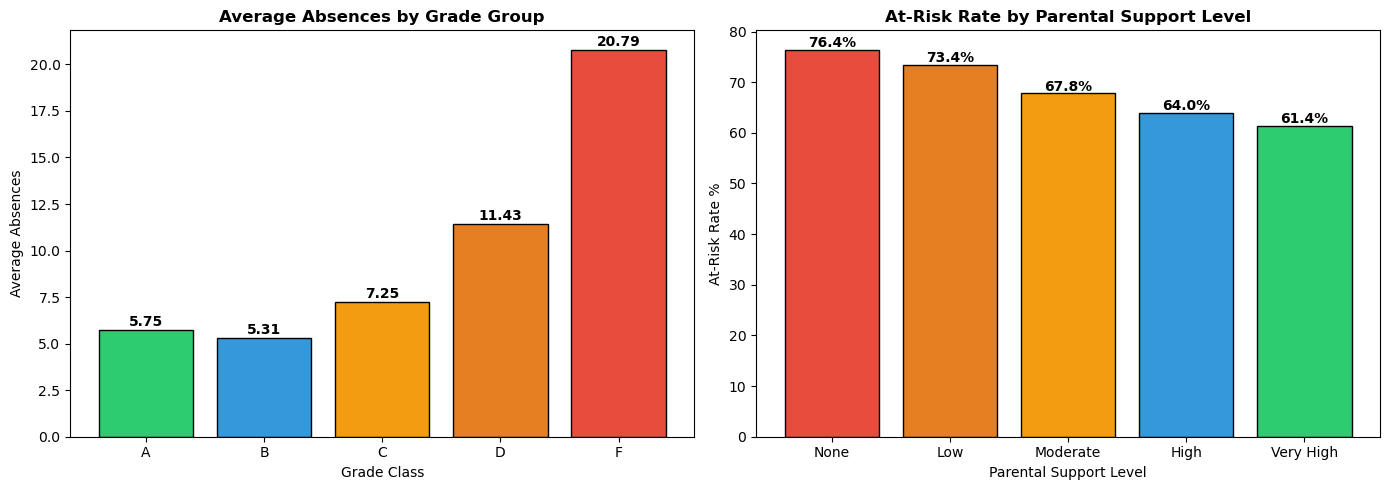

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Absences by Grade Group
grade_order = ['A', 'B', 'C', 'D', 'F']
avg_absences = segment['Avg_Absences']
colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
axes[0].bar(grade_order, avg_absences, color=colors, edgecolor='black')
axes[0].set_title('Average Absences by Grade Group', fontweight='bold')
axes[0].set_xlabel('Grade Class')
axes[0].set_ylabel('Average Absences')
for i, v in enumerate(avg_absences):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

# Plot 2 - At Risk Rate by Parental Support
support_order = ['None', 'Low', 'Moderate', 'High', 'Very High']
at_risk_support = df.groupby('ParentalSupport')['Risk_Level']\
    .apply(lambda x: (x == 'At Risk').mean() * 100)\
    .reindex(support_order)
axes[1].bar(support_order, at_risk_support, 
            color=['#e74c3c','#e67e22','#f39c12','#3498db','#2ecc71'], 
            edgecolor='black')
axes[1].set_title('At-Risk Rate by Parental Support Level', fontweight='bold')
axes[1].set_xlabel('Parental Support Level')
axes[1].set_ylabel('At-Risk Rate %')
for i, v in enumerate(at_risk_support):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('key_findings.png', dpi=150)
plt.show()

In [73]:
!pip install openpyxl

In [74]:
import openpyxl
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.drawing.image import Image as XLImage

wb = Workbook()

print("openpyxl ready")

openpyxl ready


In [75]:
ws1 = wb.active
ws1.title = "Executive Summary"

# ── Helper styles ──────────────────────────────────────────
dark_blue  = "1F3864"
mid_blue   = "2E75B6"
light_blue = "D6E4F0"
green      = "1E8449"
red        = "C0392B"
white      = "FFFFFF"
light_grey = "F2F2F2"

def cell_style(ws, row, col, value,
               bold=False, fontsize=11, color="000000",
               bg=None, align="left", wrap=False):
    c = ws.cell(row=row, column=col, value=value)
    c.font      = Font(bold=bold, size=fontsize, color=color)
    c.alignment = Alignment(horizontal=align,
                            vertical="center", wrap_text=wrap)
    if bg:
        c.fill = PatternFill("solid", fgColor=bg)
    return c

def thin_border(ws, row, col):
    side = Side(style="thin", color="BFBFBF")
    ws.cell(row=row, column=col).border = Border(
        left=side, right=side, top=side, bottom=side)

# ── Column widths ──────────────────────────────────────────
for col, w in [(1,30),(2,25),(3,25),(4,25),(5,25)]:
    ws1.column_dimensions[get_column_letter(col)].width = w

ws1.row_dimensions[1].height = 15
ws1.row_dimensions[2].height = 40
ws1.row_dimensions[3].height = 15

# ── Title banner ───────────────────────────────────────────
ws1.merge_cells("A2:E2")
cell_style(ws1, 2, 1,
           "Student Success Analytics — Retention & Performance KPIs",
           bold=True, fontsize=18, color=white, bg=dark_blue, align="center")

ws1.merge_cells("A3:E3")
cell_style(ws1, 3, 1,
           "Prepared for Academic Planning | Dataset: Students Performance Dataset (Kaggle)",
           fontsize=10, color=white, bg=mid_blue, align="center")

# ── Date & dataset info ────────────────────────────────────
ws1.row_dimensions[5].height = 20
cell_style(ws1, 5, 1, "Report Date:",   bold=True, bg=light_grey)
cell_style(ws1, 5, 2, "March 2026",              bg=light_grey)
cell_style(ws1, 6, 1, "Total Students:", bold=True, bg=light_grey)
cell_style(ws1, 6, 2, 2392,                      bg=light_grey)
cell_style(ws1, 7, 1, "Variables Analyzed:", bold=True, bg=light_grey)
cell_style(ws1, 7, 2, "GPA, Absences, Study Time, Parental Support, Tutoring, Demographics", bg=light_grey)

# ── KPI section header ─────────────────────────────────────
ws1.row_dimensions[9].height = 25
ws1.merge_cells("A9:E9")
cell_style(ws1, 9, 1, "KEY PERFORMANCE INDICATORS",
           bold=True, fontsize=12, color=white, bg=mid_blue, align="center")

# ── KPI cards (row 11) ─────────────────────────────────────
ws1.row_dimensions[10].height = 15
ws1.row_dimensions[11].height = 50
ws1.row_dimensions[12].height = 25

kpis = [
    (1, "RETENTION RATE",  "32.1%",  green),
    (2, "AT-RISK RATE",    "67.9%",  red),
    (3, "AVERAGE GPA",     "1.91",   mid_blue),
    (4, "TOTAL AT-RISK",   "1,625",  red),
    (5, "STUDENTS ON TRACK","767",   green),
]
for col, label, value, color in kpis:
    cell_style(ws1, 11, col, value,
               bold=True, fontsize=22, color=color,
               bg=light_blue, align="center")
    cell_style(ws1, 12, col, label,
               bold=True, fontsize=9, color=white,
               bg=mid_blue, align="center")
    for r in [11, 12]:
        thin_border(ws1, r, col)

# ── Executive Summary text ─────────────────────────────────
ws1.row_dimensions[14].height = 25
ws1.merge_cells("A14:E14")
cell_style(ws1, 14, 1, "EXECUTIVE SUMMARY",
           bold=True, fontsize=12, color=white, bg=mid_blue, align="center")

summary_lines = [
    (15, "Analysis of 2,392 students reveals a critical retention crisis — only 32.1% of students are performing "
         "at grade C or above, while 67.9% (1,625 students) are classified as at-risk (Grade D or F)."),
    (17, "Absences emerged as the single strongest risk factor, with a correlation of -0.919 with GPA. "
         "Students who achieve Grade A miss an average of 5.75 days, compared to 20.79 days for failing students — "
         "a 3.6x difference."),
    (19, "Parental support level significantly affects student outcomes. Students with no parental support have a "
         "76.4% at-risk rate compared to 61.4% for those with very high support — a 15 percentage point gap."),
    (21, "Tutoring shows a modest positive effect (+0.29 GPA improvement), while parental education level shows "
         "negligible impact on GPA (0.13 range across all education levels)."),
]

for row, text in summary_lines:
    ws1.row_dimensions[row].height = 45
    ws1.merge_cells(f"A{row}:E{row}")
    cell_style(ws1, row, 1, text,
               fontsize=10, bg=light_grey if row % 2 == 1 else white,
               wrap=True)

print("Sheet 1 - Executive Summary built ✅")

Sheet 1 - Executive Summary built ✅


In [76]:
ws2 = wb.create_sheet("Key Findings")

# Column widths
for col, w in [(1,8),(2,35),(3,55),(4,25)]:
    ws2.column_dimensions[get_column_letter(col)].width = w

# Title
ws2.row_dimensions[2].height = 40
ws2.merge_cells("A2:D2")
cell_style(ws2, 2, 1, "Key Findings — Student Success Analytics",
           bold=True, fontsize=16, color=white, bg=dark_blue, align="center")

ws2.merge_cells("A3:D3")
cell_style(ws2, 3, 1, "Statistical analysis of 2,392 student records | March 2026",
           fontsize=10, color=white, bg=mid_blue, align="center")

# Table header
ws2.row_dimensions[5].height = 25
for col, label in [(1,"#"),(2,"Category"),(3,"Finding"),(4,"Supporting Data")]:
    cell_style(ws2, 5, col, label,
               bold=True, fontsize=11, color=white, bg=mid_blue, align="center")
    thin_border(ws2, 5, col)

# Findings data
findings = [
    (1,  "Overall Performance",
     "Average GPA across all students is 1.91 out of 4.0, indicating a broadly struggling student population.",
     "Mean GPA = 1.91, Std = 0.92"),
    (2,  "Grade Distribution",
     "50.6% of students are failing (Grade F). Only 4.5% achieve Grade A. The majority (67.9%) are Grade D or F.",
     "F: 1211 | D: 414 | C: 391 | B: 269 | A: 107"),
    (3,  "Retention Rate",
     "Overall student retention rate is 32.1%. Nearly 7 in 10 students are classified as at-risk.",
     "On Track: 767 | At Risk: 1,625"),
    (4,  "Absences — Primary Risk Factor",
     "Absences has a -0.919 correlation with GPA — the strongest predictor of poor performance in the dataset.",
     "Correlation = -0.919 (very strong)"),
    (5,  "Absences by Grade Group",
     "Grade A students miss 5.75 days on average vs Grade F students who miss 20.79 days — a 3.6x difference.",
     "A: 5.75 | B: 5.31 | C: 7.25 | D: 11.43 | F: 20.79"),
    (6,  "Study Time",
     "Study time has a weak positive correlation with GPA (+0.179). Studying more helps but cannot overcome high absences.",
     "Correlation = +0.179 (weak)"),
    (7,  "Statistical Significance",
     "ANOVA confirms absences and study time differences across grade groups are statistically significant (p < 0.0001).",
     "Absences F=903.1 | StudyTime F=11.3 | p≈0.000"),
    (8,  "Parental Support",
     "Students with no parental support have a 76.4% at-risk rate vs 61.4% for very high support — a 15pt gap.",
     "None: 76.4% | Low: 73.4% | High: 64.0% | Very High: 61.4%"),
    (9,  "Parental Education",
     "Parental education level shows negligible impact on GPA. Range across all levels is only 0.13 GPA points.",
     "Range: 1.81 (Bachelors) to 1.94 (High School)"),
    (10, "Tutoring Effect",
     "Students receiving tutoring average 2.11 GPA vs 1.82 without — a modest but meaningful +0.29 improvement.",
     "With Tutoring: 2.11 | Without: 1.82"),
    (11, "Gender",
     "Gender shows minimal difference in at-risk rates. Female: 68.9% vs Male: 66.9% — not a meaningful differentiator.",
     "Female at-risk: 68.9% | Male: 66.9%"),
]

for i, (num, category, finding, data) in enumerate(findings):
    row = i + 6
    ws2.row_dimensions[row].height = 45
    bg = light_grey if i % 2 == 0 else white

    cell_style(ws2, row, 1, num,
               bold=True, align="center", bg=bg)
    cell_style(ws2, row, 2, category,
               bold=True, bg=bg)
    cell_style(ws2, row, 3, finding,
               bg=bg, wrap=True)
    cell_style(ws2, row, 4, data,
               fontsize=9, bg=bg, wrap=True)
    for col in range(1, 5):
        thin_border(ws2, row, col)

print("Sheet 2 - Key Findings built ✅")

Sheet 2 - Key Findings built ✅


In [77]:
ws3 = wb.create_sheet("Segment Analysis")

# Column widths
for col, w in [(1,20),(2,18),(3,18),(4,18),(5,18),(6,18)]:
    ws3.column_dimensions[get_column_letter(col)].width = w

# Title
ws3.row_dimensions[2].height = 40
ws3.merge_cells("A2:F2")
cell_style(ws3, 2, 1, "Segment Analysis — Student Performance Breakdown",
           bold=True, fontsize=16, color=white, bg=dark_blue, align="center")

# ── Table 1: Grade Group Summary ───────────────────────────
ws3.row_dimensions[4].height = 25
ws3.merge_cells("A4:F4")
cell_style(ws3, 4, 1, "TABLE 1 — Performance by Grade Group",
           bold=True, fontsize=12, color=white, bg=mid_blue, align="center")

headers1 = ["Grade", "Students", "% of Total", "Avg GPA", "Avg Absences", "Avg Study Time"]
for col, h in enumerate(headers1, 1):
    ws3.row_dimensions[5].height = 22
    cell_style(ws3, 5, col, h, bold=True, color=white, bg=mid_blue, align="center")
    thin_border(ws3, 5, col)

grade_colors = {"A": "1E8449", "B": "2E75B6", "C": "F39C12", "D": "E67E22", "F": "C0392B"}
for i, grade in enumerate(['A','B','C','D','F']):
    row = i + 6
    ws3.row_dimensions[row].height = 22
    s = segment.loc[grade]
    pct = round(s['Student_Count'] / 2392 * 100, 1)
    row_data = [grade, int(s['Student_Count']), f"{pct}%",
                round(s['Avg_GPA'], 2), round(s['Avg_Absences'], 2),
                round(s['Avg_StudyTime'], 2)]
    for col, val in enumerate(row_data, 1):
        cell_style(ws3, row, col, val,
                   bold=(col==1), align="center",
                   bg=grade_colors[grade] if col == 1 else (light_grey if i%2==0 else white),
                   color=white if col==1 else "000000")
        thin_border(ws3, row, col)

# ── Table 2: Parental Support ──────────────────────────────
ws3.row_dimensions[13].height = 25
ws3.merge_cells("A13:F13")
cell_style(ws3, 13, 1, "TABLE 2 — Performance by Parental Support Level",
           bold=True, fontsize=12, color=white, bg=mid_blue, align="center")

headers2 = ["Parental Support", "Avg GPA", "At-Risk Rate %", "Student Count", "", ""]
for col, h in enumerate(headers2, 1):
    ws3.row_dimensions[14].height = 22
    cell_style(ws3, 14, col, h, bold=True, color=white, bg=mid_blue, align="center")
    thin_border(ws3, 14, col)

support_order = ['None', 'Low', 'Moderate', 'High', 'Very High']
support_gpa = df.groupby('ParentalSupport')['GPA'].mean().round(2)
support_risk = df.groupby('ParentalSupport')['Risk_Level']\
    .apply(lambda x: round((x=='At Risk').mean()*100, 1))
support_count = df.groupby('ParentalSupport')['StudentID'].count()

for i, support in enumerate(support_order):
    row = i + 15
    ws3.row_dimensions[row].height = 22
    bg = light_grey if i % 2 == 0 else white
    for col, val in enumerate([support, support_gpa[support],
                                f"{support_risk[support]}%",
                                int(support_count[support])], 1):
        cell_style(ws3, row, col, val, align="center", bg=bg)
        thin_border(ws3, row, col)

# ── Table 3: Tutoring Effect ───────────────────────────────
ws3.row_dimensions[22].height = 25
ws3.merge_cells("A22:F22")
cell_style(ws3, 22, 1, "TABLE 3 — Impact of Tutoring on Performance",
           bold=True, fontsize=12, color=white, bg=mid_blue, align="center")

headers3 = ["Tutoring", "Avg GPA", "At-Risk Rate %", "Student Count", "", ""]
for col, h in enumerate(headers3, 1):
    ws3.row_dimensions[23].height = 22
    cell_style(ws3, 23, col, h, bold=True, color=white, bg=mid_blue, align="center")
    thin_border(ws3, 23, col)

tutoring_gpa   = df.groupby('Tutoring')['GPA'].mean().round(2)
tutoring_risk  = df.groupby('Tutoring')['Risk_Level']\
    .apply(lambda x: round((x=='At Risk').mean()*100, 1))
tutoring_count = df.groupby('Tutoring')['StudentID'].count()

for i, t in enumerate(['No','Yes']):
    row = i + 24
    ws3.row_dimensions[row].height = 22
    bg = light_grey if i % 2 == 0 else white
    for col, val in enumerate([t, tutoring_gpa[t],
                                f"{tutoring_risk[t]}%",
                                int(tutoring_count[t])], 1):
        cell_style(ws3, row, col, val, align="center", bg=bg)
        thin_border(ws3, row, col)

print("Sheet 3 - Segment Analysis built ✅")

Sheet 3 - Segment Analysis built ✅


In [78]:
ws4 = wb.create_sheet("Raw Data")

# Title
ws4.merge_cells("A1:O1")
cell_style(ws4, 1, 1, "Raw Dataset — Student Performance (Cleaned)",
           bold=True, fontsize=13, color=white, bg=dark_blue, align="center")

# Column headers
for col, header in enumerate(df.columns, 1):
    ws4.column_dimensions[get_column_letter(col)].width = 18
    cell_style(ws4, 2, col, header,
               bold=True, color=white, bg=mid_blue, align="center")
    thin_border(ws4, 2, col)

# Write data rows
for i, row_data in enumerate(df.values):
    row = i + 3
    bg = light_grey if i % 2 == 0 else white
    for col, val in enumerate(row_data, 1):
        cell_style(ws4, row, col, val, bg=bg, align="center")

print("Sheet 4 - Raw Data built ✅")

Sheet 4 - Raw Data built ✅


In [79]:
from openpyxl.drawing.image import Image as XLImage

ws5 = wb.create_sheet("Charts & Visualizations")

# Title
ws5.merge_cells("A1:L1")
cell_style(ws5, 1, 1, "Charts & Visualizations — Student Success Analytics",
           bold=True, fontsize=14, color=white, bg=dark_blue, align="center")

# Set row and column sizes for chart display
for col in range(1, 13):
    ws5.column_dimensions[get_column_letter(col)].width = 12
for row in range(1, 80):
    ws5.row_dimensions[row].height = 20

# Chart labels
cell_style(ws5, 3, 1, "Grade Distribution",
           bold=True, fontsize=11, bg=mid_blue, color=white)
cell_style(ws5, 3, 7, "Correlation with GPA",
           bold=True, fontsize=11, bg=mid_blue, color=white)
cell_style(ws5, 33, 1, "Key Findings — Absences & Parental Support",
           bold=True, fontsize=11, bg=mid_blue, color=white)

# Insert saved chart images
charts = [
    ("grade_distribution.png",  4,  1),
    ("correlation_heatmap.png", 4,  7),
    ("key_findings.png",        34, 1),
]

base_path = r"C:\Users\chand\OneDrive\Student Success Analytics\plots"

for filename, row, col in charts:
    full_path = os.path.join(base_path, filename)
    if os.path.exists(full_path):
        img = XLImage(full_path)
        img.width  = 400
        img.height = 280
        ws5.add_image(img, f"{get_column_letter(col)}{row}")
        print(f"✅ Added {filename}")
    else:
        print(f"❌ Not found: {full_path}")



✅ Added grade_distribution.png
✅ Added correlation_heatmap.png
✅ Added key_findings.png


In [80]:
import os

# Save to your downloads folder
output_path = r"C:\Users\chand\OneDrive\Student Success Analytics\student_success_report.xlsx"
wb.save(output_path)
print(f"Report saved successfully → {output_path}")

Report saved successfully → C:\Users\chand\OneDrive\Student Success Analytics\student_success_report.xlsx
